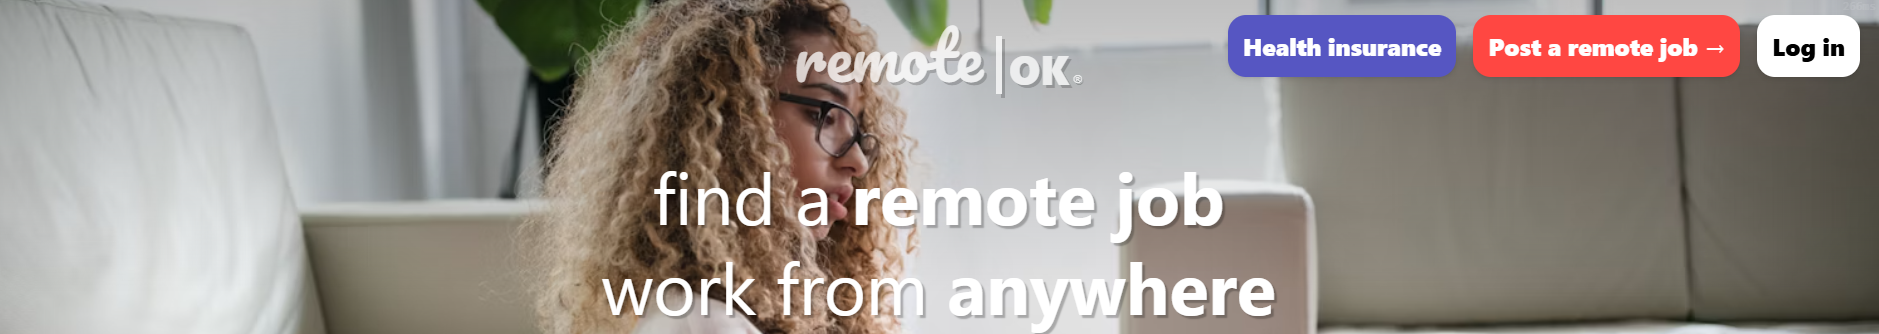

## **Introduction**

In this task, the objective is to demonstrate the process of **web scraping and analysis of job postings** from a static HTML file. The HTML file was saved from the RemoteOK job board and contains job listings with information such as job titles, company names, locations, posted dates, and required skills.

Since many job websites are dynamic and include bot protections, using a static HTML page allows safe and reproducible data extraction without relying on live requests.

**The workflow includes the following steps:**

* Uploading and reading the static HTML file.
* Extracting structured information (job title, company, location, skills, date) using **BeautifulSoup**.
* Cleaning and preparing the dataset for analysis.
* Conducting a **skill frequency analysis** to identify the most in-demand technologies and tools.
* Visualizing results through multiple charts, including bar charts, word clouds, pie charts, heatmaps, and trend lines.
* Performing additional insights, such as filtering jobs by specific skills, analyzing job locations, and comparing company skill requirements.

This approach transforms unstructured web data into meaningful insights about the **remote job market**, highlighting demand trends and providing actionable information for candidates and organizations.

--------------------------------------------------------------------------------

# **Importing Libraries**

In [ ]:
from bs4 import BeautifulSoup
import pandas as pd
import requests
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
!pip install requests beautifulsoup4 lxml
!pip install wordcloud

# **Uploading and Reading the Static HTML File**

In [ ]:
from google.colab import files
uploaded = files.upload()

html_file = list(uploaded.keys())[0]
print("Uploaded:", html_file)


Saving Remote Jobs in Programming, Design, Sales and more #OpenSalaries.html to Remote Jobs in Programming, Design, Sales and more #OpenSalaries.html
Uploaded: Remote Jobs in Programming, Design, Sales and more #OpenSalaries.html


# **Extracting Job Data**

In [ ]:

with open(html_file, "r", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "lxml")

jobs_data = []

# Each job listing row
job_rows = soup.find_all("tr", class_="job")

for job in job_rows:
    title = job.find("h2", itemprop="title")
    company = job.find("h3", itemprop="name")
    location = job.find("div", class_="location")
    date = job.find("time")

    # --- Try 1: Skills from <span class="tag"> ---
    skills_list = [tag.get_text(strip=True) for tag in job.find_all("span", class_="tag")]

    # --- Try 2: If empty, look inside <td class="tags"> ---
    if not skills_list:
        tags_td = job.find("td", class_="tags")
        if tags_td:
            skills_list = [t.get_text(strip=True) for t in tags_td.find_all("h3")]

    # --- Try 3: If still empty, check 'data-tags' attribute ---
    if not skills_list:
        data_tags = job.get("data-tags", "")
        if data_tags:
            skills_list = [s.strip() for s in data_tags.split(",") if s.strip()]

    jobs_data.append({
        "Title": title.get_text(strip=True) if title else None,
        "Company": company.get_text(strip=True) if company else None,
        "Location": location.get_text(strip=True) if location else "Remote",
        "Skills": ", ".join(skills_list) if skills_list else "Not Specified",
        "Posted Date": date.get_text(strip=True) if date else None
    })

df = pd.DataFrame(jobs_data)
df.head(20)


,Title,Company,Location,Skills,Posted Date
0,$30 Hourly Virtual Assistant USA RESIDENTS ONLY,HOLDON NOW,🇺🇸 United States,"Admin, Customer Support, Data Entry, Customer ...",3d
1,Product Engineer,Tolt,🌏 Worldwide,"JavaScript, Typescript, React, Product, AWS, E...",7d
2,Assistant Trader,Exora,🌏 Worldwide,"Finance, Sales, Crypto, Junior",9h
3,Senior Elixir Engineer,Sanctuary Computer,🌏 Worldwide,"Executive, Developer, Backend, Full Stack, Saa...",16h
4,Data Analyst,P2P. org,Delhi,"Analyst, Defi, Crypto, System, Consultancy, Te...",18h
5,Senior Staff Security Engineer,Ethena Labs,Globally Remote,"Security, Defi, Crypto, Ethereum, Full-Stack, ...",19h
6,VIP Support Manager,GoMining,🌏 Probably worldwide,"Manager, Defi, Crypto, Support, Management, Sa...",22h
7,Public Training Associate,The Trevor Project,🌏 Worldwide,"Training, Support, Travel, Financial, Edu, Man...",1d
8,FullStack Engineer,NTD software,💃 Latin America,"Developer, Design, React, Front End, Technical...",1d
9,Cryptocurrency Reporter,Find,🌏 Probably worldwide,"Cryptocurrency, Crypto, Content",2d


# **Data Cleaning and Preparation**

In [ ]:
df.drop_duplicates(inplace=True)
df.fillna("Not Specified", inplace=True)
df["Skills"] = df["Skills"].str.lower()

df.head(20)


,Title,Company,Location,Skills,Posted Date
0,$30 Hourly Virtual Assistant USA RESIDENTS ONLY,HOLDON NOW,🇺🇸 United States,"admin, customer support, data entry, customer ...",3d
1,Product Engineer,Tolt,🌏 Worldwide,"javascript, typescript, react, product, aws, e...",7d
2,Assistant Trader,Exora,🌏 Worldwide,"finance, sales, crypto, junior",9h
3,Senior Elixir Engineer,Sanctuary Computer,🌏 Worldwide,"executive, developer, backend, full stack, saa...",16h
4,Data Analyst,P2P. org,Delhi,"analyst, defi, crypto, system, consultancy, te...",18h
5,Senior Staff Security Engineer,Ethena Labs,Globally Remote,"security, defi, crypto, ethereum, full-stack, ...",19h
6,VIP Support Manager,GoMining,🌏 Probably worldwide,"manager, defi, crypto, support, management, sa...",22h
7,Public Training Associate,The Trevor Project,🌏 Worldwide,"training, support, travel, financial, edu, man...",1d
8,FullStack Engineer,NTD software,💃 Latin America,"developer, design, react, front end, technical...",1d
9,Cryptocurrency Reporter,Find,🌏 Probably worldwide,"cryptocurrency, crypto, content",2d


# **Skill Frequency Analysis**

In [ ]:
from collections import Counter

all_skills = []
for skills in df["Skills"]:
    all_skills.extend([s.strip() for s in skills.split(",") if s.strip() and s != "not specified"])

skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(skill_counts.items(), columns=["Skill", "Count"]).sort_values(by="Count", ascending=False)
skill_df.head(20)


,Skill,Count
31,support,18
9,engineer,17
45,management,12
30,technical,12
19,senior,12
15,developer,11
38,software,10
16,backend,9
32,growth,8
43,engineering,8


# **Filter Jobs by a Specific Skill (python)**

In [ ]:
skill_to_filter = "python"

python_jobs = df[df["Skills"].str.contains(skill_to_filter, case=False, na=False)]
print(f"Number of jobs requiring {skill_to_filter}: {len(python_jobs)}")

python_jobs.head(10)


Number of jobs requiring python: 2


,Title,Company,Location,Skills,Posted Date
3,Senior Elixir Engineer,Sanctuary Computer,🌏 Worldwide,"executive, developer, backend, full stack, saa...",16h
36,Senior Python Backend Engineer,Orga AI,🌏 Worldwide,"developer, python, senior, backend, ops, start...",19d


# **Count Jobs by Location**

In [ ]:
location_counts = df["Location"].value_counts().reset_index()
location_counts.columns = ["Location", "Job Count"]
location_counts.head(10)


,Location,Job Count
0,🌏 Worldwide,16
1,🌏 Probably worldwide,10
2,🇺🇸 United States,9
3,💃 Latin America,2
4,🇪🇺 Europe,2
5,Delhi,1
6,Globally Remote,1
7,🇵🇭 Philippines,1
8,🇮🇳 India,1
9,Palo Alto,1


# **Analyze Skills by Company**

In [ ]:
# Count of skills per company
company_skills = df.groupby("Company")["Skills"].apply(lambda x: ", ".join(x)).reset_index()

# Count of unique skills for each company
company_skills["Unique Skill Count"] = company_skills["Skills"].apply(lambda x: len(set([s.strip() for s in x.split(",") if s.strip()])))
company_skills.sort_values("Unique Skill Count", ascending=False).head(10)


,Company,Skills,Unique Skill Count
8,CoinGecko,"cryptocurrency, hr, system, training, technica...",23
15,FetLife,"engineer, ruby, vue, redis, rust, kubernetes, ...",21
21,InfStones,"amazon, web3, system, security, support, softw...",21
3,Arbitrum Foundation,"developer, web3, cryptocurrency, ethereum, sec...",18
27,NTD software,"developer, design, react, front end, technical...",17
12,Ethena Labs,"security, defi, crypto, ethereum, full-stack, ...",16
40,Virta Health,"software, front end, security, training, full-...",16
1,Anchorage Digital,"growth, crypto, security, testing, financial, ...",14
38,The Trevor Project,"training, support, travel, financial, edu, man...",13
34,Sanctuary Computer,"executive, developer, backend, full stack, saa...",13


# **Visualization of Skills**

**Bar Chart: Top 10 skills and Top 10 locations in job listing**


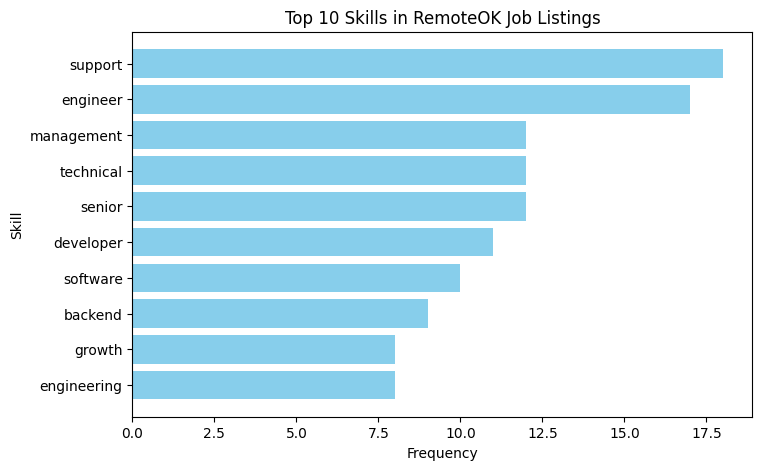

In [ ]:
import matplotlib.pyplot as plt

top_skills = skill_df.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_skills["Skill"], top_skills["Count"], color="skyblue")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.title("Top 10 Skills in RemoteOK Job Listings")
plt.gca().invert_yaxis()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127759 (\N{EARTH GLOBE ASIA-AUSTRALIA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128131 (\N{DANCER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  f

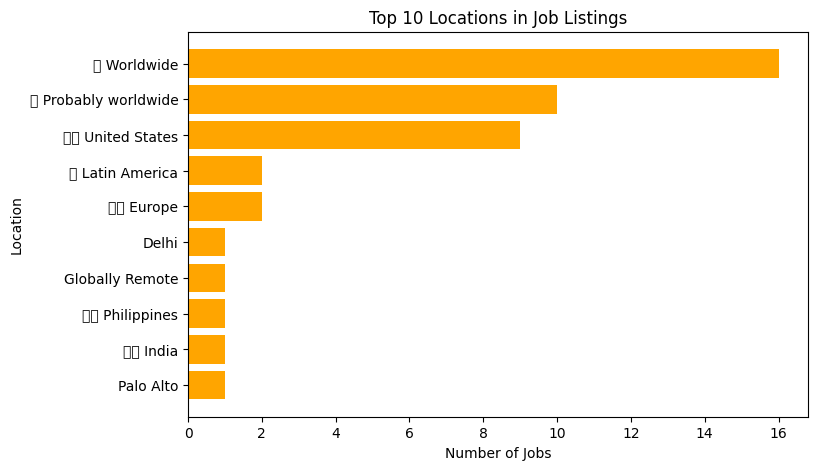

In [ ]:
import matplotlib.pyplot as plt

top_locations = location_counts.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_locations["Location"], top_locations["Job Count"], color="orange")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.title("Top 10 Locations in Job Listings")
plt.gca().invert_yaxis()
plt.show()

**Word Cloud: Most common skills.**



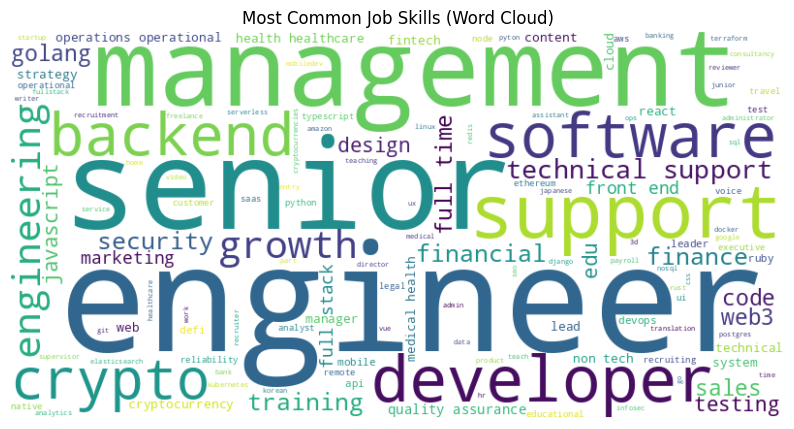

In [ ]:
text = " ".join(all_skills)

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Job Skills (Word Cloud)")
plt.show()


**Pie Chart: Skill distribution.**



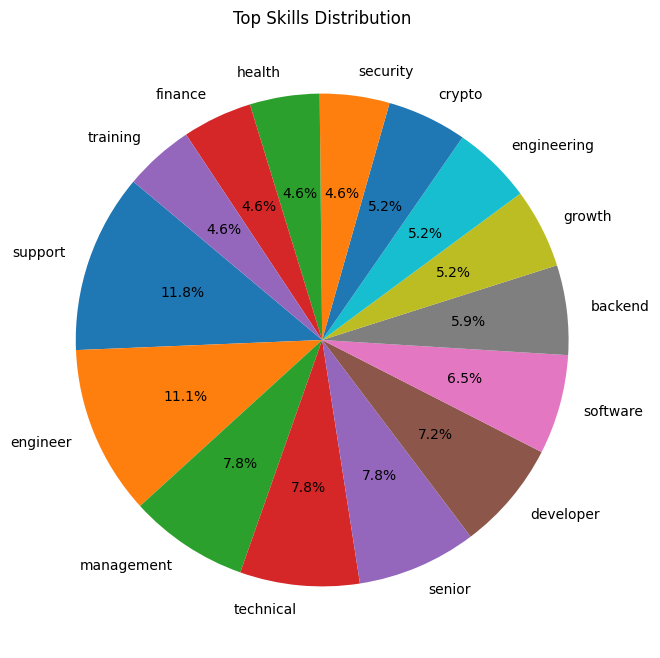

In [ ]:
top_skills = skill_df.head(15)

plt.figure(figsize=(8,8))
plt.pie(top_skills["Count"], labels=top_skills["Skill"], autopct='%1.1f%%', startangle=140)
plt.title("Top Skills Distribution")
plt.show()


**Heatmap: Skills vs Companies.**

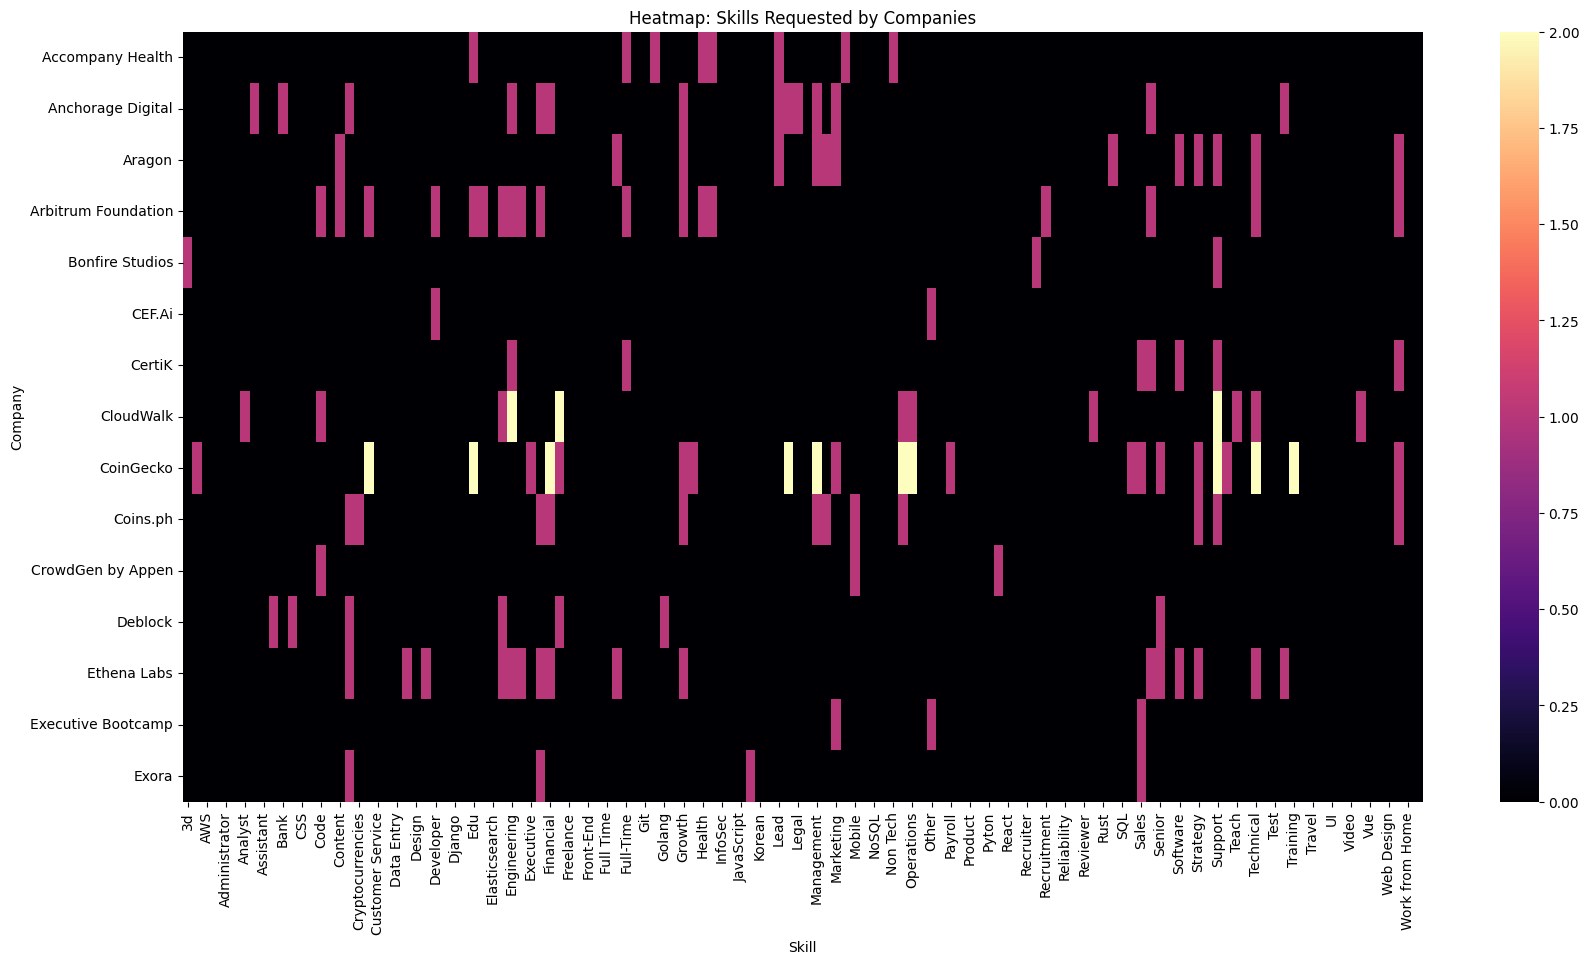

In [ ]:
# Expand skills into separate rows
expanded_df = df.assign(Skill=df["Skills"].str.split(",")).explode("Skill")
expanded_df["Skill"] = expanded_df["Skill"].str.strip()

# Pivot table: Companies vs Skills
pivot = pd.crosstab(expanded_df["Company"], expanded_df["Skill"])

# Plot heatmap (only top 15 companies to keep it readable)
plt.figure(figsize=(20,10))
sns.heatmap(pivot.head(15), cmap="magma", cbar=True)
plt.title("Heatmap: Skills Requested by Companies")
plt.show()


**Timeline of Postings**

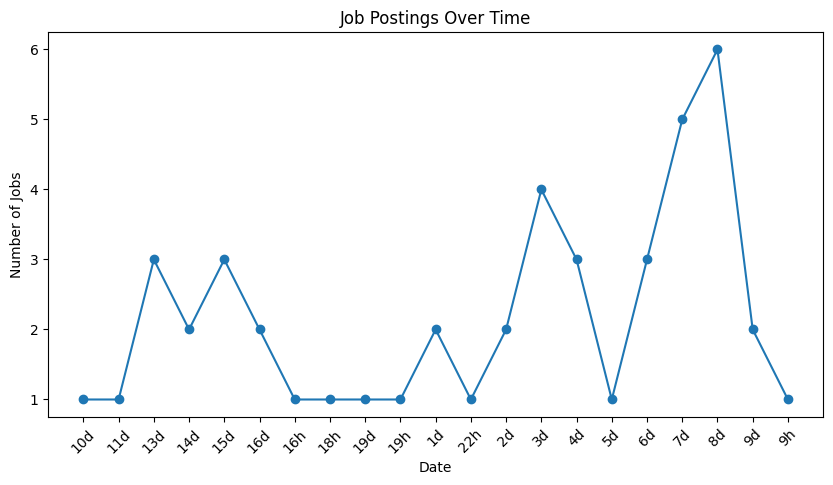

In [ ]:
date_counts = df["Posted Date"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(date_counts.index, date_counts.values, marker="o", linestyle="-")
plt.xlabel("Date")
plt.ylabel("Number of Jobs")
plt.title("Job Postings Over Time")
plt.xticks(rotation=45)
plt.show()


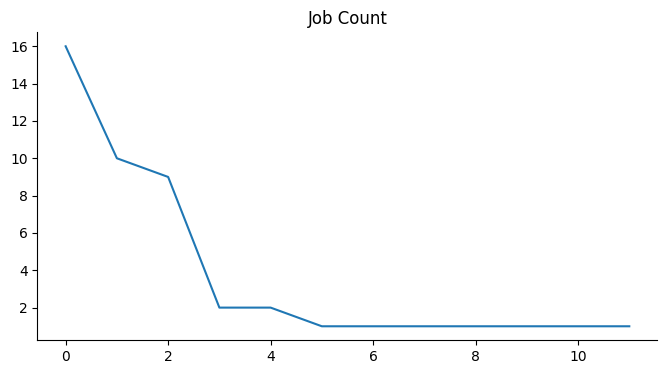

In [ ]:
location_counts['Job Count'].plot(kind='line', figsize=(8, 4), title='Job Count')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df.to_csv("scraped_jobs.csv", index=False)
print("Saved scraped job data to scraped_jobs.csv")


Saved scraped job data to scraped_jobs.csv
